# **Long-term Annual & Seasonal Temperature Trends**

**Study Period:** 1910 - 2025

**Seasonal Breakdown:**
 - Summer (December, January & February)
 - Autumn (March, April & May)
 - Winter (June, July & August)
 - Spring (September, October & November)

**Script Output:**
 - mornington_annual_temperature_trend.png
 - mornington_seasonal_temperature_trend.png

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import pymannkendall as mk

# Mornington Peninsula bounding box
lat_min, lat_max = -38.50, -38.05
lon_min, lon_max = 144.68, 145.35


CACHE_DIR = '/scratch/ob22/ft3359/mornington_cache'

tmax_grid = xr.open_dataarray(f'{CACHE_DIR}/tmax_grid_masked.nc').load()
tmin_grid = xr.open_dataarray(f'{CACHE_DIR}/tmin_grid_masked.nc').load()

print(f"tmax subset shape: {tmax_grid.shape} "
      f"(lat: {tmax_grid.lat.size}, lon: {tmax_grid.lon.size}, time: {tmax_grid.time.size})")
print(f"tmin subset shape: {tmin_grid.shape} "
      f"(lat: {tmin_grid.lat.size}, lon: {tmin_grid.lon.size}, time: {tmin_grid.time.size})")

# Spatial mean over the box
tmax_box_mean = tmax_grid.mean(dim=['lat', 'lon'], skipna=True)
tmin_box_mean = tmin_grid.mean(dim=['lat', 'lon'], skipna=True)

/g/data/xp65/admin/analysis3/sitecustomize.py:72: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  mod = _real_import(name, globals, locals, fromlist, level)


tmax subset shape: (42369, 10, 14) (lat: 10, lon: 14, time: 42369)
tmin subset shape: (42369, 10, 14) (lat: 10, lon: 14, time: 42369)


In [2]:
# Helpers: Mann-Kendall trend stats + CV/IQR variability
def trend_stats(years, values, min_n=4):
    # Return dict with Mann-Kendall/Sen's slope trend stats
    mask = ~np.isnan(values)
    years_c, values_c = years[mask], values[mask]

    if len(values_c) < min_n:
        return {
            'sen_slope_per_decade': np.nan,
            'sen_intercept': np.nan,
            'mk_p': np.nan,
            'mk_trend': 'insufficient data',
            'mk_z': np.nan,
            'n_years': len(values_c),
        }

    mk_result = mk.original_test(values_c)
    sen_slope_per_decade = mk_result.slope * 10
    sen_intercept = np.median(values_c) - mk_result.slope * np.median(years_c)

    return {
        'sen_slope_per_decade': sen_slope_per_decade,
        'sen_intercept': sen_intercept,
        'mk_p': mk_result.p,
        'mk_trend': mk_result.trend,
        'mk_z': mk_result.z,
        'n_years': len(years_c),
    }


def fmt_trend_label(stats_dict):
    if np.isnan(stats_dict['mk_p']):
        return f"insufficient data (n={stats_dict['n_years']})"
    sig = 'significant' if stats_dict['mk_p'] < 0.05 else 'not significant'
    if stats_dict['mk_p'] < 0.001:
        p_str = "p<0.001"
    else:
        p_str = f"p={stats_dict['mk_p']:.3f}"
    return f"{p_str} ({sig})"


def variability_stats(values):
    # Return dict with CV and IQR for a 1D array of annual/seasonal means
    v = values[~np.isnan(values)]
    mean = np.mean(v)
    sd = np.std(v, ddof=1)
    cv = sd / mean if mean != 0 else np.nan
    q75, q25 = np.percentile(v, [75, 25])
    iqr = q75 - q25
    return {
        'mean_degC': mean,
        'sd_degC': sd,
        'cv': cv,
        'iqr_degC': iqr,
        'q25_degC': q25,
        'q75_degC': q75,
        'n_years': len(v),
    }


def fmt_variability(stats_dict):
    return (f"mean={stats_dict['mean_degC']:.2f}°C, sd={stats_dict['sd_degC']:.2f}°C, "
            f"CV={stats_dict['cv']:.3f}, IQR={stats_dict['iqr_degC']:.2f}°C "
            f"(n={stats_dict['n_years']})")


# Completeness-filtered annual/seasonal mean helper
def annual_mean_clean(box_mean, min_frac=0.9):
    # Resample to annual mean, dropping years with <min_frac of days present
    annual_mean = box_mean.resample(time='YS').mean(skipna=True)
    annual_count = box_mean.resample(time='YS').count()
    annual_expected = annual_mean['time'].dt.is_leap_year.astype(int) * 366 + \
                       (~annual_mean['time'].dt.is_leap_year).astype(int) * 365
    complete_mask = (annual_count / annual_expected) >= min_frac
    dropped = int((~complete_mask).sum())
    return annual_mean.where(complete_mask).compute(), dropped


def seasonal_mean_clean(box_mean, min_frac=0.9):
    # Resample to seasonal (QS-DEC) mean, dropping incomplete seasons
    seasonal_mean = box_mean.resample(time='QS-DEC').mean(skipna=True)
    seasonal_count = box_mean.resample(time='QS-DEC').count()

    def days_in_season(ts):
        end = ts + pd.DateOffset(months=3)
        return (end - ts).days

    expected_days_arr = np.array(
        [days_in_season(pd.Timestamp(t)) for t in seasonal_mean['time'].values]
    )
    complete_mask = (seasonal_count.values / expected_days_arr) >= min_frac
    seasonal_mean_clean_da = seasonal_mean.where(
        xr.DataArray(complete_mask, dims='time', coords={'time': seasonal_mean.time})
    )
    return seasonal_mean_clean_da.compute()

In [3]:
# Run analysis for a given temperature variable

def analyse_temperature(box_mean, label):
    # Compute annual + seasonal trend/variability stats for one variable
    annual_clean, dropped = annual_mean_clean(box_mean)
    print(f"[{label}] Dropped {dropped} incomplete year(s) out of {annual_clean.time.size}.")
 
    years = annual_clean['time'].dt.year.values.astype(float)
    values = annual_clean.values
    trend = trend_stats(years, values)
    variability = variability_stats(values)
 
    print(f"[{label}] Annual trend: {trend}")
    print(f"[{label}] Annual variability: {fmt_variability(variability)}")
 
    seasonal_clean = seasonal_mean_clean(box_mean)
    season_labels = seasonal_clean['time'].dt.month.values
    season_years = seasonal_clean['time'].dt.year.values
 
    seasonal_results = {}
    for month in [12, 3, 6, 9]:
        sel = season_labels == month
        yrs = season_years[sel].astype(float)
        vals = seasonal_clean.values[sel]
        n_valid = int((~np.isnan(vals)).sum())
        if n_valid < 4:
            print(f"[{label}] WARNING: only {n_valid} valid year(s) for month={month} "
                  f"— trend stats will be NaN for this season.")
        seasonal_results[month] = {
            'years': yrs,
            'values': vals,
            'trend': trend_stats(yrs, vals),
            'variability': variability_stats(vals),
        }
 
    return {
        'years': years,
        'values': values,
        'trend': trend,
        'variability': variability,
        'seasonal': seasonal_results,
    }
 
 
tmax_results = analyse_temperature(tmax_box_mean, 'tmax')
tmin_results = analyse_temperature(tmin_box_mean, 'tmin')

[tmax] Dropped 0 incomplete year(s) out of 116.
[tmax] Annual trend: {'sen_slope_per_decade': 0.07926913821193302, 'sen_intercept': 3.179429915078547, 'mk_p': 1.0894519997250995e-06, 'mk_trend': 'increasing', 'mk_z': 4.87475205899623, 'n_years': 116}
[tmax] Annual variability: mean=18.78°C, sd=0.58°C, CV=0.031, IQR=0.78°C (n=116)
[tmin] Dropped 0 incomplete year(s) out of 116.
[tmin] Annual trend: {'sen_slope_per_decade': 0.1253671038384531, 'sen_intercept': -14.419053279886057, 'mk_p': 0.0, 'mk_trend': 'increasing', 'mk_z': 8.35842215499941, 'n_years': 116}
[tmin] Annual variability: mean=10.29°C, sd=0.58°C, CV=0.056, IQR=0.84°C (n=116)


Saved: mornington_annual_temperature_trend.png
Saved: mornington_seasonal_temperature_trends.png


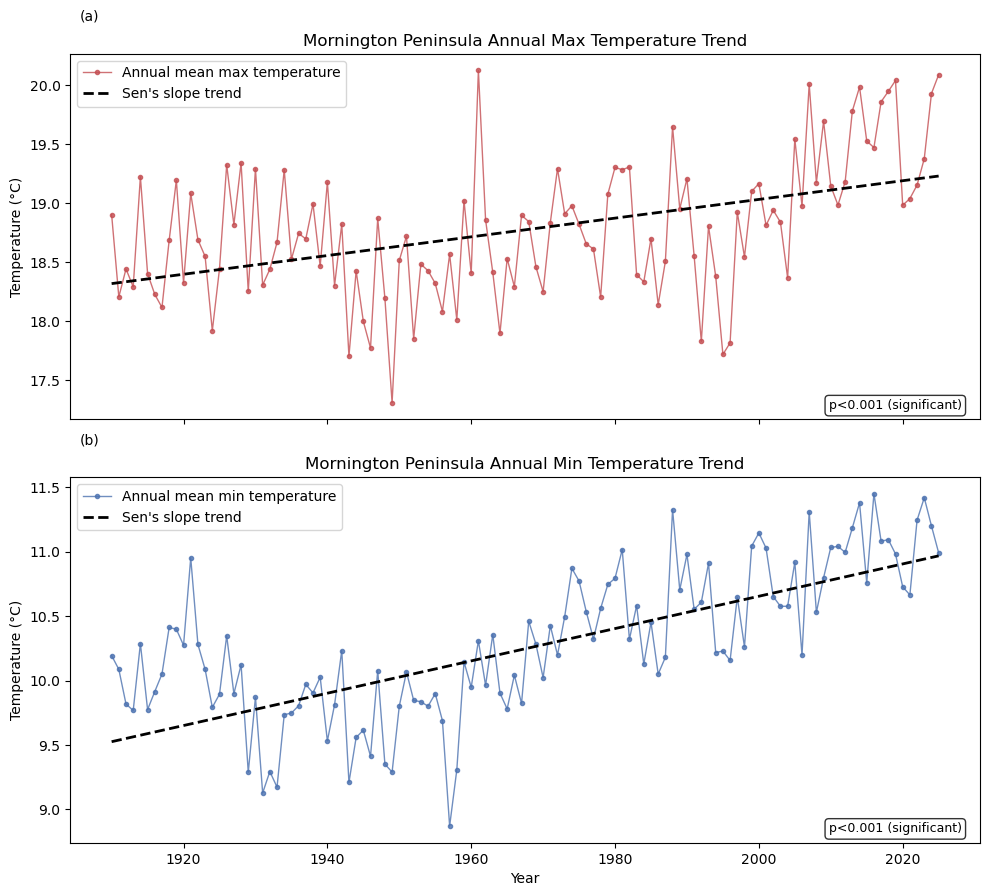

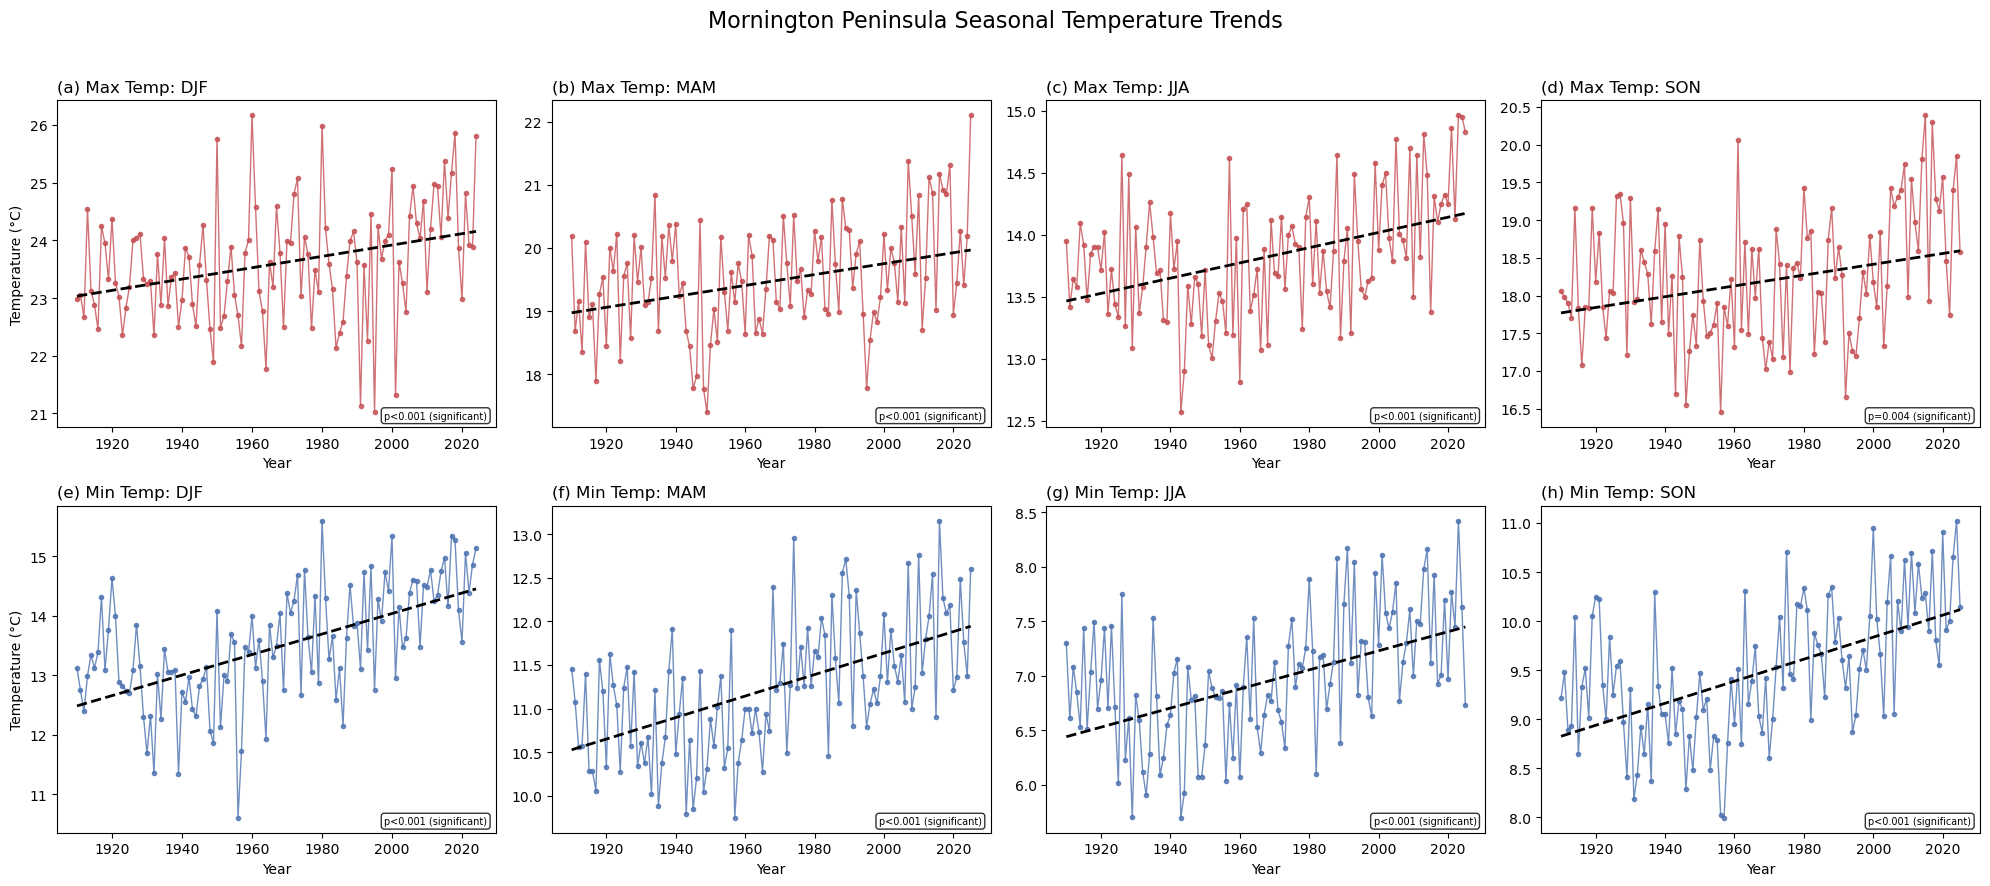

In [4]:
# Annual trend plot: tmax + tmin

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)
panel_labels = ['(a)', '(b)']

for ax, results, label, color, panel_label in zip(
    axes, [tmax_results, tmin_results], ['Max Temperature', 'Min Temperature'],
    ['#C44E52', '#4C72B0'], panel_labels
):
    years, values, trend = results['years'], results['values'], results['trend']
    mask = ~np.isnan(values)
    
    ax.plot(years[mask], values[mask], color=color, marker='o', markersize=3,
             linewidth=1, alpha=0.8, label=f'Annual mean {label.lower()}')
    
    fit_line = trend['sen_intercept'] + (trend['sen_slope_per_decade'] / 10) * years[mask]
    
    ax.plot(years[mask], fit_line, color='black', linewidth=2, linestyle='--',
             label="Sen's slope trend")
    
    ax.set_title(f'Mornington Peninsula Annual {label} Trend')
    
    ax.text(0.01, 1.12, panel_label, transform=ax.transAxes,
             fontsize=10, fontweight='normal', va='top', ha='left')
    
    ax.set_ylabel('Temperature (°C)')
    ax.legend(loc='upper left')
    ax.text(0.98, 0.02, fmt_trend_label(trend),
             transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
axes[-1].set_xlabel('Year')
fig.tight_layout()
fig.savefig('mornington_annual_temperature_trend.png', dpi=200)
print("Saved: mornington_annual_temperature_trend.png")


# Seasonal trend plot: tmax (top row) + tmin (bottom row)

season_names = {12: 'DJF', 3: 'MAM', 6: 'JJA', 9: 'SON'}
season_order = [12, 3, 6, 9]
panel_letters = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)']

fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharex=False)

panel_idx = 0
for row, (results, label, color) in enumerate(zip(
    [tmax_results, tmin_results], ['Max Temp', 'Min Temp'], ['#C44E52', '#4C72B0']
)):
    for col, month in enumerate(season_order):
        ax = axes[row, col]
        season_data = results['seasonal'][month]
        yrs, vals, trend = season_data['years'], season_data['values'], season_data['trend']
        mask = ~np.isnan(vals)

        ax.plot(yrs[mask], vals[mask], color=color, marker='o', markersize=3,
                 linewidth=1, alpha=0.8)

        fit_line = trend['sen_intercept'] + (trend['sen_slope_per_decade'] / 10) * yrs[mask]
        ax.plot(yrs[mask], fit_line, color='black', linewidth=2, linestyle='--')

        ax.set_title(f'{panel_letters[panel_idx]} {label}: {season_names[month]}', loc='left')
        ax.set_xlabel('Year')
        if col == 0:
            ax.set_ylabel('Temperature (°C)')
        ax.text(0.98, 0.02, fmt_trend_label(trend),
                 transform=ax.transAxes, ha='right', va='bottom', fontsize=7,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        panel_idx += 1

fig.suptitle('Mornington Peninsula Seasonal Temperature Trends', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig('mornington_seasonal_temperature_trends.png', dpi=200)
print("Saved: mornington_seasonal_temperature_trends.png")

In [22]:
# Seasonal variability summary

for results, label in zip([tmax_results, tmin_results], ['tmax', 'tmin']):
    print(f"\n[{label}] Seasonal variability")
    for month in season_order:
        vstats = results['seasonal'][month]['variability']
        print(f"  {season_names[month]}: {fmt_variability(vstats)}")
 

# Clean up the Dask cluster

client.close()
cluster.close()


[tmax] Seasonal variability
  DJF: mean=23.6°C, SD=1.00°C, CV=0.042, IQR=1.21°C (Q25=22.9, Q75=24.1)
  MAM: mean=19.5°C, SD=0.86°C, CV=0.044, IQR=1.21°C (Q25=19.0, Q75=20.2)
  JJA: mean=13.8°C, SD=0.50°C, CV=0.036, IQR=0.63°C (Q25=13.5, Q75=14.1)
  SON: mean=18.3°C, SD=0.84°C, CV=0.046, IQR=1.21°C (Q25=17.6, Q75=18.8)

[tmin] Seasonal variability
  DJF: mean=13.5°C, SD=0.97°C, CV=0.072, IQR=1.40°C (Q25=12.9, Q75=14.3)
  MAM: mean=11.2°C, SD=0.75°C, CV=0.067, IQR=1.03°C (Q25=10.6, Q75=11.7)
  JJA: mean=7.0°C, SD=0.58°C, CV=0.084, IQR=0.81°C (Q25=6.6, Q75=7.4)
  SON: mean=9.5°C, SD=0.68°C, CV=0.071, IQR=1.03°C (Q25=9.0, Q75=10.0)


# **Number of Days with Maximum Temp over 30, 35, 40 °C Analysis**

In [6]:
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import pymannkendall as mk

warnings.filterwarnings('ignore', category=UserWarning, module='dask')
warnings.filterwarnings('ignore', category=FutureWarning, module='xarray')

base_path = '/g/data/zv2/agcd/v1-0-4'
lat_min, lat_max = -38.50, -38.05
lon_min, lon_max = 144.68, 145.35

THRESHOLDS = [30, 35, 40]
THRESHOLD_COLOURS = {30: '#fdd49e', 35: '#fc8d59', 40: '#b30000'}

# Load Tmax grid, box-averaged
def load_box(var_subpath, var_name):
    ds = xr.open_mfdataset(
        f'{base_path}/{var_subpath}/*.nc',
        combine='by_coords',
        data_vars='minimal', 
    )
    da = ds[var_name].sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
    da = da.chunk({'lat': -1, 'lon': -1})
    return da.load()

tmax_grid = load_box('tmax/mean/r005/01day', 'tmax')

tmax_box_mean = tmax_grid.mean(dim=['lat', 'lon'], skipna=True)
tmax_box_series = pd.Series(
    tmax_box_mean.values,
    index=pd.to_datetime(tmax_box_mean['time'].values)
).sort_index()

print(f"Loaded Tmax bax series: {tmax_box_series.index.min().date()} to {tmax_box_series.index.max().date()}, "
      f"{len(tmax_box_series)} days")

# Helper functions

def annual_days_over(series, threshold):
    exceed = (series > threshold).astype(int)
    return exceed.resample('YS').sum()

def days_over_trend(annual_counts, min_years=10):
    s = annual_counts.dropna()
    if len(s) < min_years:
        return np.nan, np.nan, None
    result = mk.original_test(s.values)
    years = s.index.year.values
    trend_line = result.intercept + result.slope * (years - years[0])
    return result.slope, result.p, trend_line

/jobfs/177445348.gadi-pbs/ipykernel_909142/2136685354.py:20: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.open_mfdataset(
/jobfs/177445348.gadi-pbs/ipykernel_909142/2136685354.py:20: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.open_mfdataset(
/jobfs/177445348.gadi-pbs/ipykernel_909142/2136685354.py:20: FutureWarning

Loaded Tmax bax series: 1910-01-01 to 2025-12-31, 42369 days


Saved: mornington_days_over_threshold.png


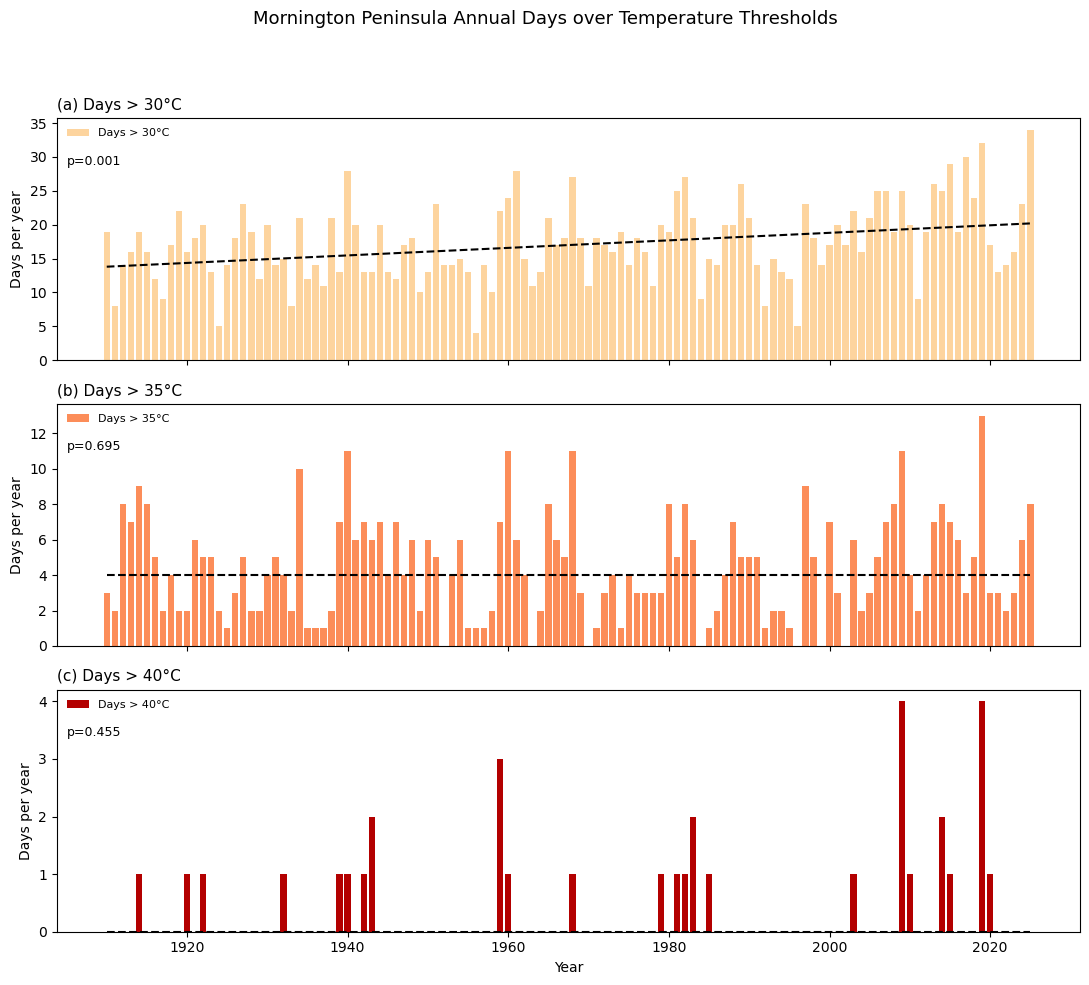

In [7]:
# Plot

panel_letters = ['(a)', '(b)', '(c)']

fig, axes = plt.subplots(len(THRESHOLDS), 1, figsize=(11, 10), sharex=True)
for ax, threshold, letter in zip(axes, THRESHOLDS, panel_letters):
    annual_counts = annual_days_over(tmax_box_series, threshold)
    years = annual_counts.index.year.values
    slope, pval, trend_line = days_over_trend(annual_counts)

    ax.bar(years, annual_counts.values, color=THRESHOLD_COLOURS[threshold],
            width=0.8, label=f'Days > {threshold}°C')
    if trend_line is not None:
        ax.plot(years, trend_line, color='black', linestyle='--', linewidth=1.5)
        p_text = f"p={pval:.3f}"
    else:
        p_text = "insufficient data"
    ax.text(0.01, 0.85, p_text, transform=ax.transAxes, ha='left', va='top', fontsize=9,
            bbox=dict(facecolor='white', edgecolor='white', boxstyle='round,pad=0.3'))
    ax.set_ylabel('Days per year')
    ax.set_title(f'{letter} Days > {threshold}°C', fontsize=11, loc='left')
    ax.legend(loc='upper left', fontsize=8, edgecolor='white')

axes[-1].set_xlabel('Year')
fig.suptitle('Mornington Peninsula Annual Days over Temperature Thresholds', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig('mornington_days_over_threshold.png', dpi=200)
print("Saved: mornington_days_over_threshold.png")

# **Number of Days with Minimum Temperature over 20, 25°C Analysis**

In [8]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pymannkendall as mk

# Mornington Peninsula bounding box
lat_min, lat_max = -38.50, -38.05
lon_min, lon_max = 144.68, 145.35
CACHE_DIR = '/scratch/ob22/ft3359/mornington_cache'

tmin_grid = xr.open_dataarray(f'{CACHE_DIR}/tmin_grid_masked.nc').load()
print(f"tmin subset shape: {tmin_grid.shape} "
      f"(lat: {tmin_grid.lat.size}, lon: {tmin_grid.lon.size}, time: {tmin_grid.time.size})")

# Spatial mean over the box
tmin_box_mean = tmin_grid.mean(dim=['lat', 'lon'], skipna=True)
tmin_box_series = pd.Series(
    tmin_box_mean.values,
    index=pd.to_datetime(tmin_box_mean['time'].values)
).sort_index()
print(f"Loaded Tmin box series: {tmin_box_series.index.min().date()} to {tmin_box_series.index.max().date()}, "
      f"{len(tmin_box_series)} days")

THRESHOLDS = [20, 25]
THRESHOLD_COLOURS = {20: '#a1d99b', 25: '#238b45'}

# Helper functions
def annual_days_over(series, threshold):
    exceed = (series > threshold).astype(int)
    return exceed.resample('YS').sum()

def days_over_trend(annual_counts, min_years=10):
    s = annual_counts.dropna()
    if len(s) < min_years:
        return np.nan, np.nan, None
    result = mk.original_test(s.values)
    years = s.index.year.values
    trend_line = result.intercept + result.slope * (years - years[0])
    return result.slope, result.p, trend_line

tmin subset shape: (42369, 10, 14) (lat: 10, lon: 14, time: 42369)
Loaded Tmin box series: 1910-01-01 to 2025-12-31, 42369 days


Saved: mornington_min_days_over_threshold.png


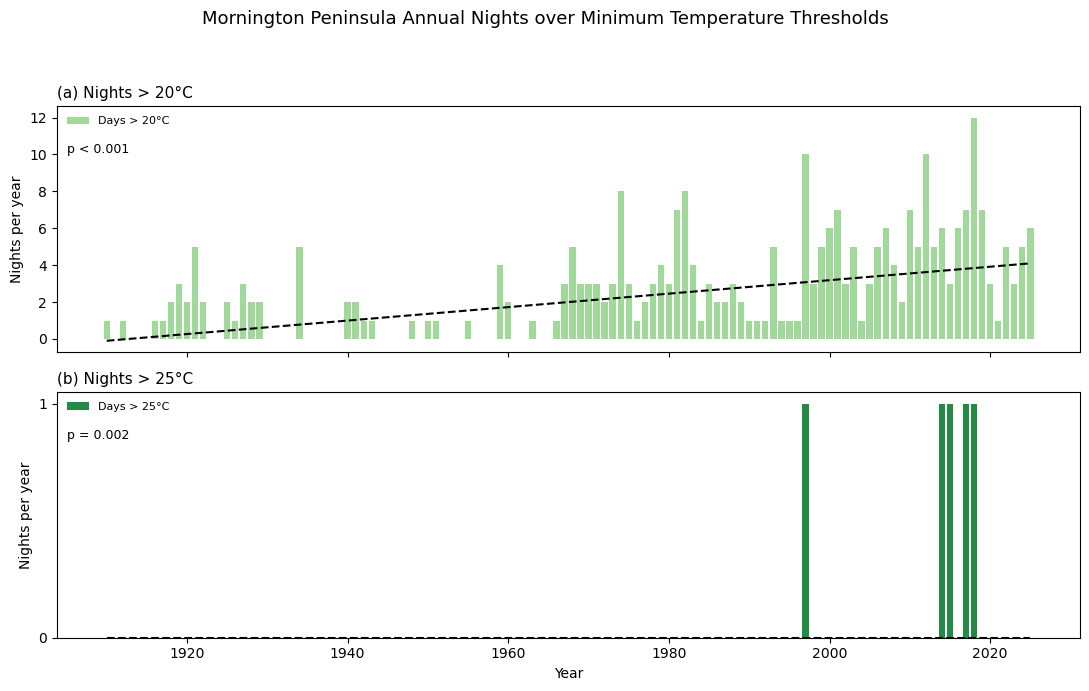

In [9]:
# Plot
panel_letters = ['(a)', '(b)']
fig, axes = plt.subplots(len(THRESHOLDS), 1, figsize=(11, 7), sharex=True)
for ax, threshold, letter in zip(axes, THRESHOLDS, panel_letters):
    annual_counts = annual_days_over(tmin_box_series, threshold)
    years = annual_counts.index.year.values
    slope, pval, trend_line = days_over_trend(annual_counts)
    ax.bar(years, annual_counts.values, color=THRESHOLD_COLOURS[threshold],
            width=0.8, label=f'Days > {threshold}°C')
    if trend_line is not None:
        ax.plot(years, trend_line, color='black', linestyle='--', linewidth=1.5)
        p_text = "p < 0.001" if pval < 0.001 else f"p = {pval:.3f}"
    else:
        p_text = "insufficient data"
    ax.text(0.01, 0.85, p_text, transform=ax.transAxes, ha='left', va='top', fontsize=9,
            bbox=dict(facecolor='white', edgecolor='white', boxstyle='round,pad=0.3'))
    ax.set_ylabel('Nights per year')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_title(f'{letter} Nights > {threshold}°C', fontsize=11, loc='left')
    ax.legend(loc='upper left', fontsize=8, edgecolor='white')
axes[-1].set_xlabel('Year')
fig.suptitle('Mornington Peninsula Annual Nights over Minimum Temperature Thresholds', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig('mornington_min_days_over_threshold.png', dpi=200)
print("Saved: mornington_min_days_over_threshold.png")